In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_theme()

# Output folders
import os
os.makedirs("../outputs/eda", exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


In [2]:
leads = pd.read_csv("../data/leads (1).csv")
interactions = pd.read_csv("../data/interactions (1).csv")

print(f"Leads shape       : {leads.shape}")
print(f"Interactions shape: {interactions.shape}")

Leads shape       : (2045, 21)
Interactions shape: (40000, 36)


In [3]:
# Quick peek at both datasets
print("=== LEADS — first 3 rows ===")
display(leads.head(3))

print("=== INTERACTIONS — first 3 rows ===")
display(interactions.head(3))

=== LEADS — first 3 rows ===


,lead_id,source,campaign,city,state,region,device_type,browser,industry,company_size,...,annual_revenue_band,employee_count,company_age_years,funding_stage,employee_growth_band,job_role,first_touch_channel,business_email,account_type,created_at
0,LEAD-01690,Referral,Retargeting_General,Mumbai,Maharashtra,West,Mobile,Chrome,Healthcare,Large,...,10Cr-50Cr,755,15,Series A,Unknown,VP,Direct,garima.oommen@karnikltd.com,New Business,2026-02-04 11:37:23
1,LEAD-01555,Direct,Retargeting_General,Mumbai,Maharashtra,West,Desktop,Chrome,SaaS,Large,...,10Cr-50Cr,297,14,Series A,25-50%,CXO,Referral,sai.andra@yahoo.com,Partner,2026-03-06 16:13:50
2,LEAD-01284,Instagram,Startup_Founders,Mumbai,Maharashtra,West,Mobile,Opera,SaaS,Small,...,1Cr-10Cr,35,2,Bootstrapped,0-10%,Associate,Social Media - Instagram,triya.deshmukh@yahoo.com,New Business,2026-02-15 16:43:20


=== INTERACTIONS — first 3 rows ===


,interaction_id,lead_id,session_id,visitor_id,timestamp,page_name,page_category,page_url,page_depth,event_type,...,screen_size,traffic_source,utm_source,utm_medium,utm_campaign,referrer_type,session_number,is_return_visitor,previous_session_gap_days,funnel_stage
0,INT-015483,LEAD-00612,S-B7F581FEC7C5,V-E3A7D06E94,2026-07-01 00:00:00,Landing Page,landing,/lp/campaign,2,track,...,360x780,linkedin,linkedin,NaN,bfsi_jan,social,1,False,NaN,Awareness
1,INT-029965,LEAD-01737,S-EDF8EFAB7165,V-571AC6DA98,2026-05-09 03:59:23,Pricing,pricing,/pricing,5,track,...,1440x900,referral,NaN,referral,startup_apr,NaN,12,True,0.0,Evaluation
2,INT-050883,LEAD-00326,S-349F82A92570,V-BC9E4D707F,2026-01-26 05:17:02,Case Studies,social_proof,/case-studies,4,track,...,360x780,google,google,cpc,startup_apr,direct,1,False,NaN,Awareness


In [4]:
# Column types overview
print("=== LEADS DTYPES ===")
print(leads.dtypes)
print()
print("=== INTERACTIONS DTYPES ===")
print(interactions.dtypes)

=== LEADS DTYPES ===
lead_id                   str
source                    str
campaign                  str
city                      str
state                     str
region                    str
device_type               str
browser                   str
industry                  str
company_size              str
lead_segment              str
annual_revenue_band       str
employee_count          int64
company_age_years       int64
funding_stage             str
employee_growth_band      str
job_role                  str
first_touch_channel       str
business_email            str
account_type              str
created_at                str
dtype: object

=== INTERACTIONS DTYPES ===
interaction_id                   str
lead_id                          str
session_id                       str
visitor_id                       str
timestamp                        str
page_name                        str
page_category                    str
page_url                         str
page_depth

In [5]:
# Column types overview
print("=== LEADS DTYPES ===")
print(leads.dtypes)
print()
print("=== INTERACTIONS DTYPES ===")
print(interactions.dtypes)

=== LEADS DTYPES ===
lead_id                   str
source                    str
campaign                  str
city                      str
state                     str
region                    str
device_type               str
browser                   str
industry                  str
company_size              str
lead_segment              str
annual_revenue_band       str
employee_count          int64
company_age_years       int64
funding_stage             str
employee_growth_band      str
job_role                  str
first_touch_channel       str
business_email            str
account_type              str
created_at                str
dtype: object

=== INTERACTIONS DTYPES ===
interaction_id                   str
lead_id                          str
session_id                       str
visitor_id                       str
timestamp                        str
page_name                        str
page_category                    str
page_url                         str
page_depth

## Data Quality

In [6]:
# Missing values in leads
missing_leads = leads.isnull().sum().sort_values(ascending=False)
missing_leads = missing_leads[missing_leads > 0]
print("Missing values in Leads:")
print(missing_leads)
print(f"Total missing: {missing_leads.sum()} out of {leads.shape[0] * leads.shape[1]} cells")

Missing values in Leads:
browser                101
company_size           101
annual_revenue_band     42
city                    40
dtype: int64
Total missing: 284 out of 42945 cells


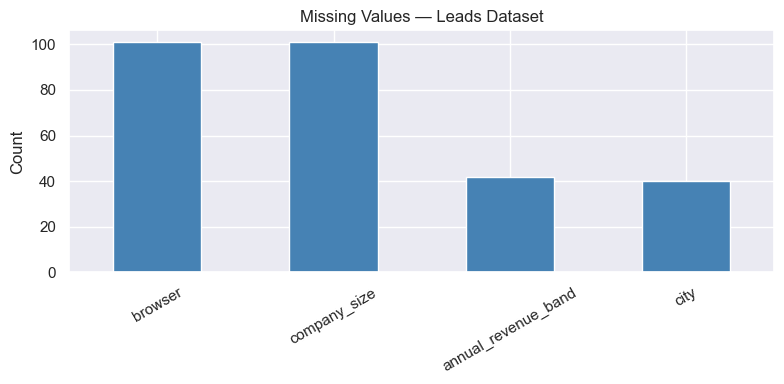

In [7]:
# Visualise missing values
plt.figure(figsize=(8, 4))
missing_leads.plot(kind="bar", color="steelblue")
plt.title("Missing Values — Leads Dataset")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../outputs/eda/missing_values_leads.png", dpi=150)
plt.show()

In [8]:
# Missing values in interactions
missing_inter = interactions.isnull().sum().sort_values(ascending=False)
missing_inter = missing_inter[missing_inter > 0]
print("Missing values in Interactions (top 10):")
print(missing_inter.head(10))
print()
print("Note: form_name/form_step missing ~80% — structurally missing (only populated on form events).")
print("UTM fields missing ~19% — direct traffic has no UTM tags. Both are expected, not errors.")

Missing values in Interactions (top 10):
form_name                    32220
form_step                    32220
cta_type                      7944
utm_medium                    7758
utm_source                    7572
button_location               6707
referrer_type                 6526
previous_session_gap_days     6271
button_name                   3869
utm_campaign                  3350
dtype: int64

Note: form_name/form_step missing ~80% — structurally missing (only populated on form events).
UTM fields missing ~19% — direct traffic has no UTM tags. Both are expected, not errors.


In [9]:
# Fill categorical missing values with "Unknown"
categorical_cols = ["city", "browser", "company_size", "annual_revenue_band"]
for col in categorical_cols:
    if col in leads.columns:
        leads[col] = leads[col].fillna("Unknown")

# Fill numeric missing values with median
leads["employee_count"]    = leads["employee_count"].fillna(leads["employee_count"].median())
leads["company_age_years"] = leads["company_age_years"].fillna(leads["company_age_years"].median())

print("Missing values after imputation:")
print(leads.isnull().sum()[leads.isnull().sum() > 0])


Missing values after imputation:
Series([], dtype: int64)


In [10]:
print(f"Total rows in leads    : {len(leads)}")
print(f"Unique lead_ids        : {leads['lead_id'].nunique()}")
print(f"Duplicate lead_ids     : {leads['lead_id'].duplicated().sum()}")

# Show duplicate records
duplicates = leads[leads["lead_id"].duplicated(keep=False)].sort_values("lead_id")
print(f"Duplicate records ({len(duplicates)} rows):")
display(duplicates.head(6))

# Remove duplicates — keep first occurrence
leads = leads.drop_duplicates(subset="lead_id", keep="first").reset_index(drop=True)
print(f"After deduplication: {len(leads)} unique leads")

Total rows in leads    : 2045
Unique lead_ids        : 2025
Duplicate lead_ids     : 20
Duplicate records (40 rows):


,lead_id,source,campaign,city,state,region,device_type,browser,industry,company_size,...,annual_revenue_band,employee_count,company_age_years,funding_stage,employee_growth_band,job_role,first_touch_channel,business_email,account_type,created_at
584,LEAD-00100,Google,Q1_BFSI_Pune,Pune,Maharashtra,West,Mobile,Chrome,SaaS,Enterprise,...,100Cr+,9048,22,Unknown,25-50%,VP,Organic Search,oeshi.reddy@yahoo.com,New Business,2026-02-27 19:28:05
2013,LEAD-00100,Google,Q1_BFSI_Pune,Pune,Maharashtra,West,Mobile,Chrome,SaaS,Enterprise,...,100Cr+,9048,22,Unknown,25-50%,VP,Organic Search,oeshi.reddy@yahoo.com,New Business,2026-02-27 19:28:05
353,LEAD-00121,Google,Q1_BFSI_Mumbai,Thane,Maharashtra,West,Desktop,Safari,Education,Large,...,50Cr-100Cr,972,11,Series C+,0-10%,Senior Manager,Display Ad,patrick.vig@outlook.com,Existing Customer,2026-01-31 13:35:59
2001,LEAD-00121,Google,Q1_BFSI_Mumbai,Thane,Maharashtra,West,Desktop,Safari,Education,Large,...,50Cr-100Cr,972,11,Series C+,0-10%,Senior Manager,Display Ad,patrick.vig@outlook.com,Existing Customer,2026-01-31 13:35:59
2012,LEAD-00162,Google,Q1_BFSI_Pune,Mumbai,Maharashtra,West,Mobile,Chrome,Technology,Medium,...,10Cr-50Cr,93,4,Series B,0-10%,Associate,Organic Search,jack.raval@yahoo.com,Partner,2026-01-05 13:16:15
1118,LEAD-00162,Google,Q1_BFSI_Pune,Mumbai,Maharashtra,West,Mobile,Chrome,Technology,Medium,...,10Cr-50Cr,93,4,Series B,0-10%,Associate,Organic Search,jack.raval@yahoo.com,Partner,2026-01-05 13:16:15


After deduplication: 2025 unique leads


Employee Count statistics:
count      2025.0
mean       2027.5
std        9942.0
min           1.0
25%         109.0
50%         348.0
75%         940.0
max      250000.0
Name: employee_count, dtype: float64



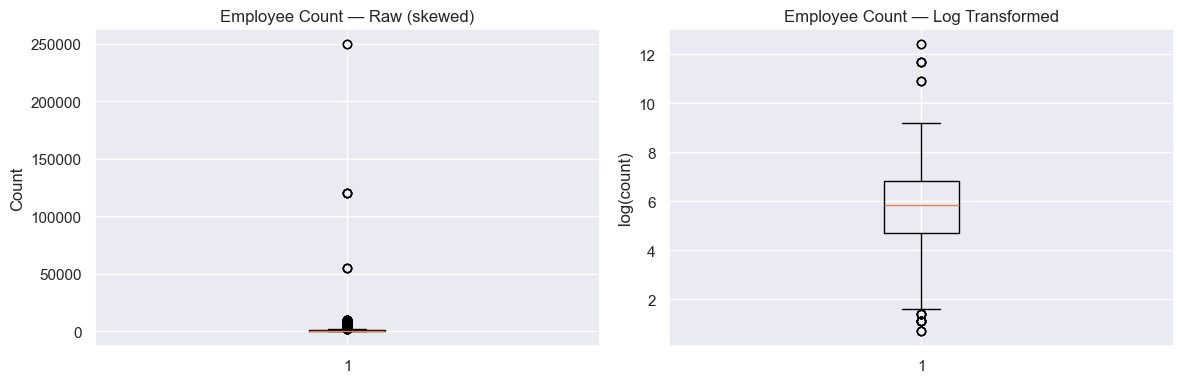

Conclusion: Values up to 250,000 are real enterprise companies, not errors.
Log transformation will be applied during feature engineering.


In [11]:
print("Employee Count statistics:")
print(leads["employee_count"].describe().round(1))
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw distribution
axes[0].boxplot(leads["employee_count"].dropna())
axes[0].set_title("Employee Count — Raw (skewed)")
axes[0].set_ylabel("Count")

# Log-transformed
axes[1].boxplot(np.log1p(leads["employee_count"].dropna()))
axes[1].set_title("Employee Count — Log Transformed")
axes[1].set_ylabel("log(count)")

plt.tight_layout()
plt.savefig("../outputs/eda/employee_count_distribution.png", dpi=150)
plt.show()

print("Conclusion: Values up to 250,000 are real enterprise companies, not errors.")
print("Log transformation will be applied during feature engineering.")

In [12]:
interactions["timestamp"] = pd.to_datetime(interactions["timestamp"], errors="coerce")
leads["created_at"]       = pd.to_datetime(leads["created_at"],   errors="coerce")

print(f"Interactions timestamp range:")
print(f"  Min: {interactions['timestamp'].min()}")
print(f"  Max: {interactions['timestamp'].max()}")
print(f"  Span: {(interactions['timestamp'].max() - interactions['timestamp'].min()).days} days")
print()

# Check for interactions before lead was created (data anomaly)
merged_check = interactions.merge(leads[["lead_id", "created_at"]], on="lead_id", how="left")
invalid_ts   = merged_check[merged_check["timestamp"] < merged_check["created_at"]]
print(f"Interactions before lead creation date: {len(invalid_ts)} rows")
if len(invalid_ts) == 0:
    print("No timestamp anomalies found — data is clean.")

Interactions timestamp range:
  Min: 2026-01-02 20:23:57
  Max: 2026-07-01 00:00:00
  Span: 179 days

Interactions before lead creation date: 0 rows
No timestamp anomalies found — data is clean.


## 4. Target Variable Creation


In [13]:
HIGH_INTENT_EVENTS = {"demo_request", "free_trial_start", "contact_form_submit"}

event_conv = set(interactions.loc[interactions["event_name"].isin(HIGH_INTENT_EVENTS), "lead_id"])
form_conv  = set(interactions.loc[interactions["form_completed"] == True, "lead_id"])
converted_ids = event_conv | form_conv

leads["converted"] = leads["lead_id"].isin(converted_ids).astype(int)

n_conv = leads["converted"].sum()
rate   = leads["converted"].mean() * 100
print(f"Converted leads : {n_conv}")
print(f"Total leads     : {len(leads)}")
print(f"Conversion rate : {rate:.1f}%")
print()
print(f"Class split — 0: {(leads.converted==0).sum()}  |  1: {(leads.converted==1).sum()}")


Converted leads : 644
Total leads     : 2025
Conversion rate : 31.8%

Class split — 0: 1381  |  1: 644


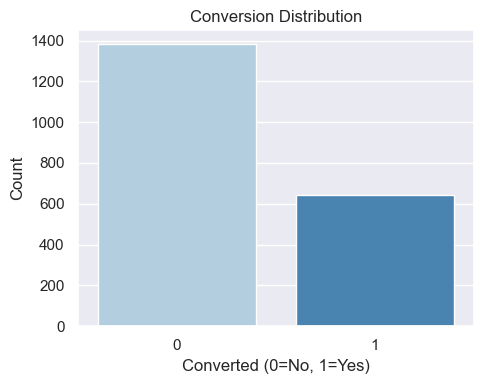

Dataset is moderately imbalanced (≈68% / 32%).
Handled during model training using class_weight=balanced.


In [14]:
plt.figure(figsize=(5, 4))
sns.countplot(x="converted", data=leads, palette="Blues")
plt.title("Conversion Distribution")
plt.xlabel("Converted (0=No, 1=Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../outputs/eda/conversion_distribution.png", dpi=150)
plt.show()

print("Dataset is moderately imbalanced (≈68% / 32%).")
print("Handled during model training using class_weight=balanced.")

## 5. Lead Profile Analysis

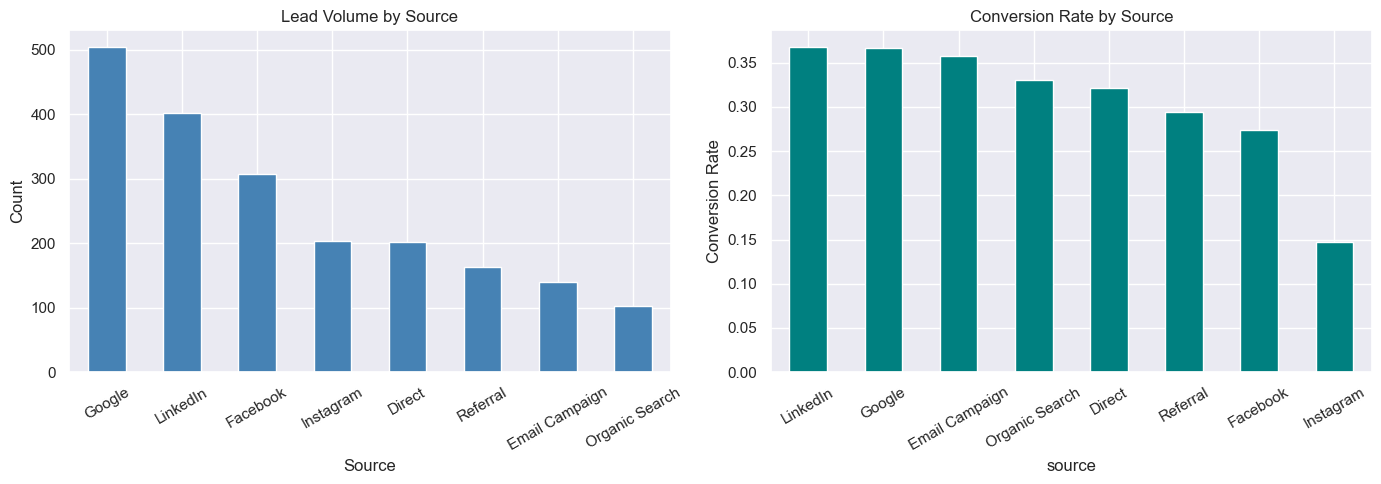

Conversion Rate by Source:
source
LinkedIn          0.368
Google            0.366
Email Campaign    0.357
Organic Search    0.330
Direct            0.322
Referral          0.294
Facebook          0.274
Instagram         0.148

Key finding: Instagram converts at ~15% vs LinkedIn/Google at ~37%.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Volume by source
leads["source"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Lead Volume by Source")
axes[0].set_xlabel("Source")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

# Conversion rate by source
source_conv = leads.groupby("source")["converted"].mean().sort_values(ascending=False)
source_conv.plot(kind="bar", ax=axes[1], color="teal")
axes[1].set_title("Conversion Rate by Source")
axes[1].set_ylabel("Conversion Rate")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../outputs/eda/conversion_by_source.png", dpi=150)
plt.show()

print("Conversion Rate by Source:")
print(source_conv.round(3).to_string())
print()
print("Key finding: Instagram converts at ~15% vs LinkedIn/Google at ~37%.")

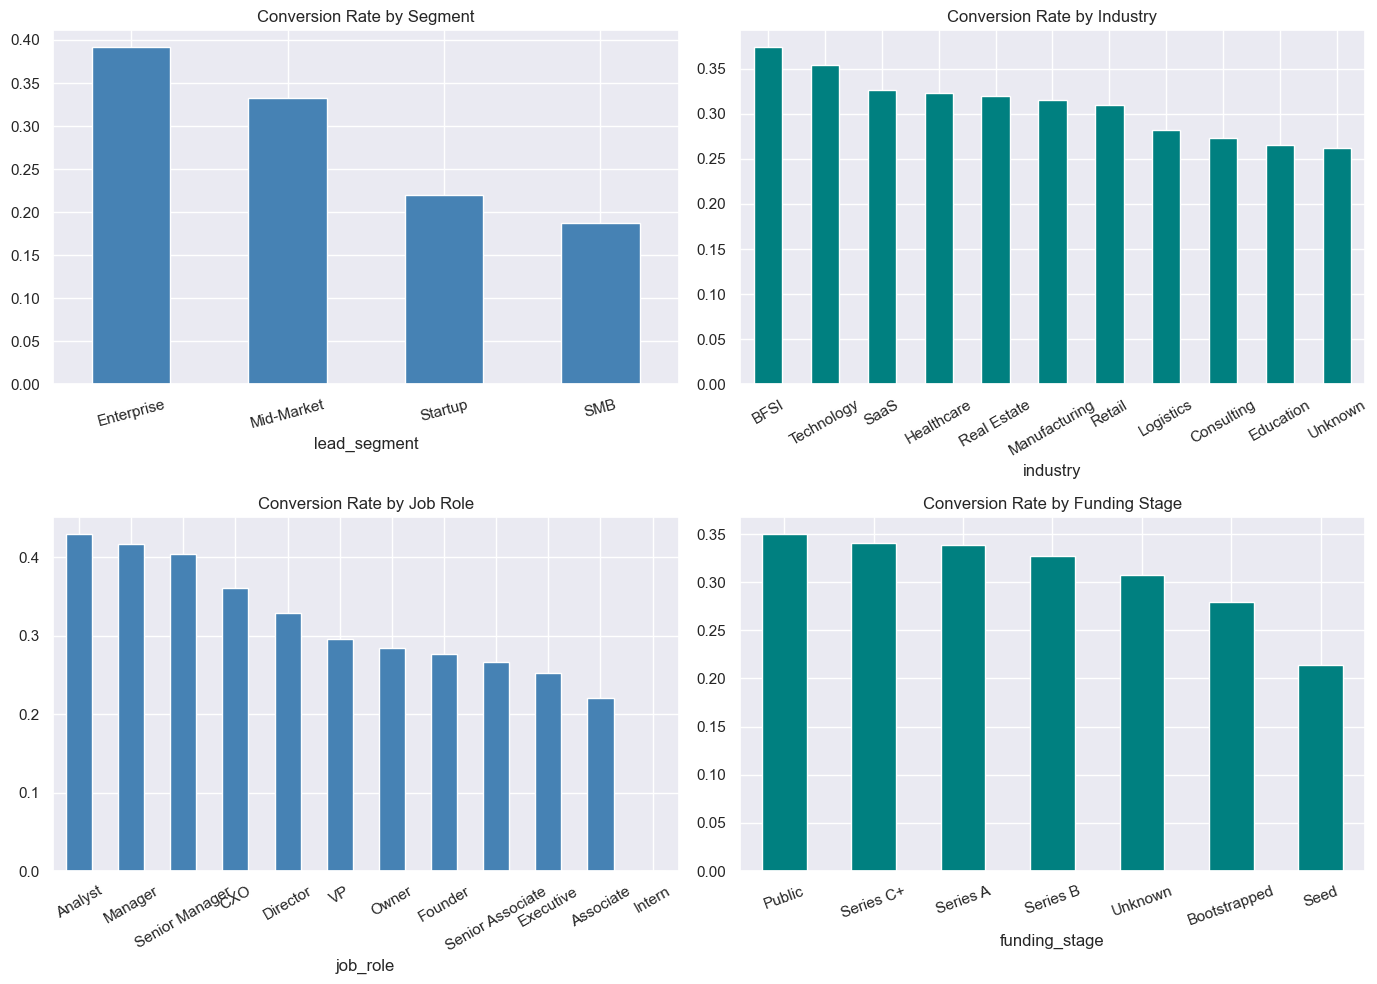

Key findings:
  Segment    — Enterprise 39.1% vs SMB 18.7%
  Industry   — BFSI top, Education bottom
  Job role   — Analyst 43.0% vs Intern 0.0%
  Funding    — Public/Series C+ top, Seed bottom


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Segment
segment_conv = leads.groupby("lead_segment")["converted"].mean().sort_values(ascending=False)
segment_conv.plot(kind="bar", ax=axes[0][0], color="steelblue")
axes[0][0].set_title("Conversion Rate by Segment")
axes[0][0].tick_params(axis="x", rotation=15)

# Industry
industry_conv = leads.groupby("industry")["converted"].mean().sort_values(ascending=False)
industry_conv.plot(kind="bar", ax=axes[0][1], color="teal")
axes[0][1].set_title("Conversion Rate by Industry")
axes[0][1].tick_params(axis="x", rotation=30)

# Job role
job_conv = leads.groupby("job_role")["converted"].mean().sort_values(ascending=False)
job_conv.plot(kind="bar", ax=axes[1][0], color="steelblue")
axes[1][0].set_title("Conversion Rate by Job Role")
axes[1][0].tick_params(axis="x", rotation=30)

# Funding stage
funding_conv = leads.groupby("funding_stage")["converted"].mean().sort_values(ascending=False)
funding_conv.plot(kind="bar", ax=axes[1][1], color="teal")
axes[1][1].set_title("Conversion Rate by Funding Stage")
axes[1][1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../outputs/eda/conversion_by_segment.png", dpi=150)
plt.show()

print("Key findings:")
print(f"  Segment    — Enterprise {segment_conv.get('Enterprise',0):.1%} vs SMB {segment_conv.get('SMB',0):.1%}")
print(f"  Industry   — BFSI top, Education bottom")
print(f"  Job role   — Analyst {job_conv.get('Analyst',0):.1%} vs Intern {job_conv.get('Intern',0):.1%}")
print(f"  Funding    — Public/Series C+ top, Seed bottom")

## 6. Behavioral Analysis


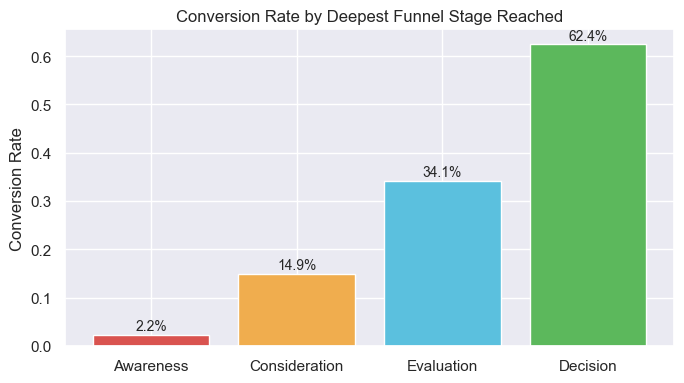

Funnel conversion rates:
  Awareness      : 2.2%
  Consideration  : 14.9%
  Evaluation     : 34.1%
  Decision       : 62.4%

Key finding: Decision stage = 62%+ conversion vs Awareness = 2%.


In [17]:
funnel_map = {"Awareness": 1, "Consideration": 2, "Evaluation": 3, "Decision": 4}
interactions["funnel_order"] = interactions["funnel_stage"].map(funnel_map)

lead_funnel = (
    interactions
    .groupby("lead_id")["funnel_order"]
    .max()
    .reset_index()
    .merge(leads[["lead_id", "converted"]], on="lead_id")
)

funnel_conv = lead_funnel.groupby("funnel_order")["converted"].mean()

plt.figure(figsize=(7, 4))
bars = plt.bar(["Awareness", "Consideration", "Evaluation", "Decision"],
               funnel_conv.values, color=["#d9534f","#f0ad4e","#5bc0de","#5cb85c"])
plt.title("Conversion Rate by Deepest Funnel Stage Reached")
plt.ylabel("Conversion Rate")
for bar, val in zip(bars, funnel_conv.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.1%}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/eda/funnel_conversion.png", dpi=150)
plt.show()

print("Funnel conversion rates:")
for stage, val in zip(["Awareness","Consideration","Evaluation","Decision"], funnel_conv.values):
    print(f"  {stage:15s}: {val:.1%}")
print()
print("Key finding: Decision stage = 62%+ conversion vs Awareness = 2%.")

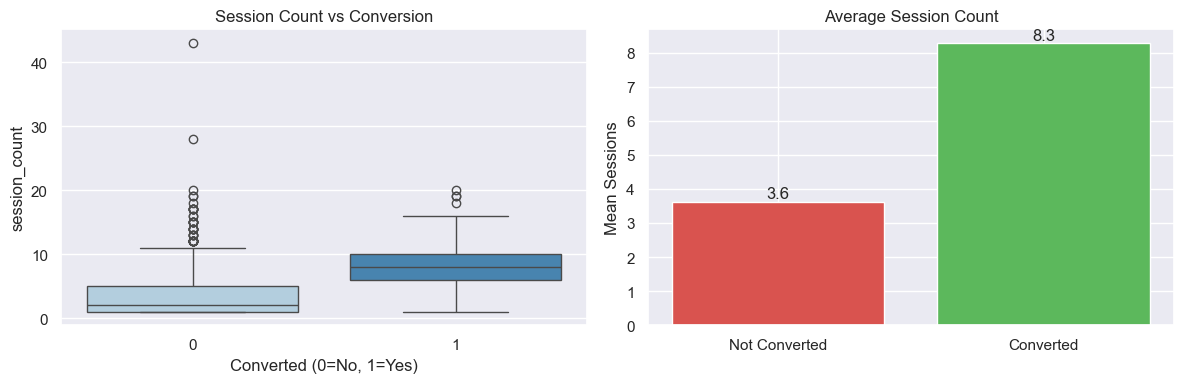

Avg sessions — Converted: 8.3  |  Not converted: 3.6
Converted leads return 2x more often.


In [18]:
sessions = (
    interactions
    .groupby("lead_id")["session_id"]
    .nunique()
    .reset_index(name="session_count")
)
merged = leads.merge(sessions, on="lead_id", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot
sns.boxplot(x="converted", y="session_count", data=merged, ax=axes[0], palette="Blues")
axes[0].set_title("Session Count vs Conversion")
axes[0].set_xlabel("Converted (0=No, 1=Yes)")

# Mean bar
mean_sessions = merged.groupby("converted")["session_count"].mean()
axes[1].bar(["Not Converted", "Converted"], mean_sessions.values, color=["#d9534f","#5cb85c"])
axes[1].set_title("Average Session Count")
axes[1].set_ylabel("Mean Sessions")
for i, v in enumerate(mean_sessions.values):
    axes[1].text(i, v + 0.1, f"{v:.1f}", ha="center")

plt.tight_layout()
plt.savefig("../outputs/eda/session_behavior.png", dpi=150)
plt.show()

print(f"Avg sessions — Converted: {mean_sessions[1]:.1f}  |  Not converted: {mean_sessions[0]:.1f}")
print("Converted leads return 2x more often.")

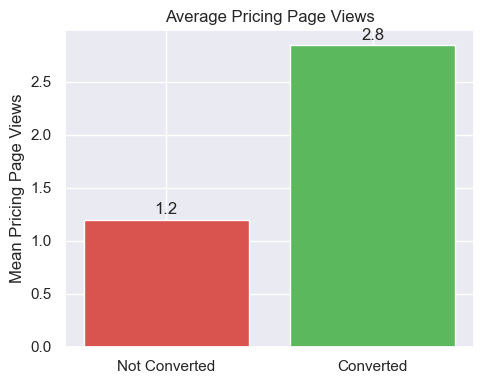

Avg pricing views — Converted: 2.8  |  Not converted: 1.2
Converted leads visit the pricing page 2x more.


In [19]:
pricing_views = (
    interactions[interactions["page_name"] == "Pricing"]
    .groupby("lead_id")
    .size()
    .reset_index(name="pricing_page_views")
)
merged2 = merged.merge(pricing_views, on="lead_id", how="left").fillna({"pricing_page_views": 0})

mean_pricing = merged2.groupby("converted")["pricing_page_views"].mean()

plt.figure(figsize=(5, 4))
plt.bar(["Not Converted", "Converted"], mean_pricing.values, color=["#d9534f","#5cb85c"])
plt.title("Average Pricing Page Views")
plt.ylabel("Mean Pricing Page Views")
for i, v in enumerate(mean_pricing.values):
    plt.text(i, v + 0.05, f"{v:.1f}", ha="center")
plt.tight_layout()
plt.savefig("../outputs/eda/pricing_page_views.png", dpi=150)
plt.show()

print(f"Avg pricing views — Converted: {mean_pricing[1]:.1f}  |  Not converted: {mean_pricing[0]:.1f}")
print("Converted leads visit the pricing page 2x more.")

## 7. Temporal Analysis

In [20]:
interactions["converted"] = interactions["lead_id"].isin(converted_ids).astype(int)
print("converted column added to interactions:", interactions["converted"].value_counts().to_dict())

converted column added to interactions: {1: 22351, 0: 17649}


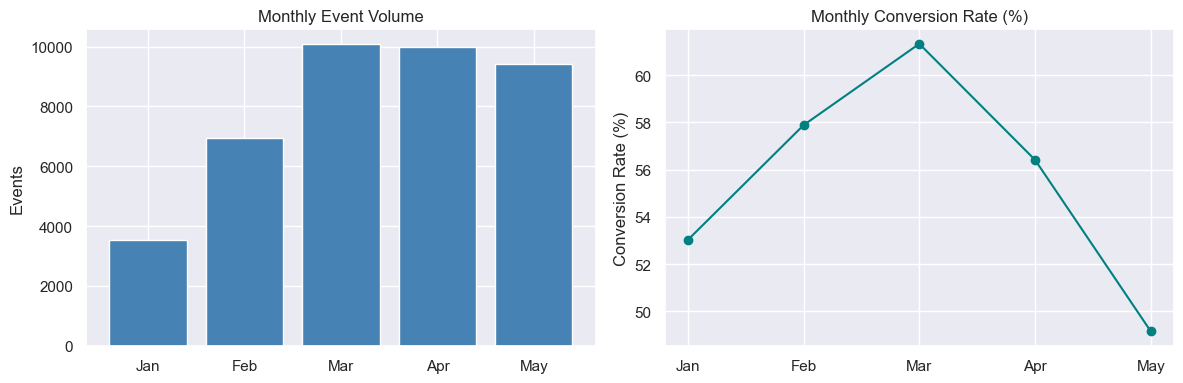

month_name  total_events  unique_leads  conv_rate
       Jan          3523           385  53.022992
       Feb          6933           747  57.882591
       Mar         10069           943  61.326845
       Apr          9987           930  56.413337
       May          9407           854  49.154885
       NaN            78            73  44.871795
       NaN             3             3  66.666667

Key finding: March = peak volume AND peak conversion rate (61%).
May = high volume but lowest conversion (49%) — lower quality traffic.


In [21]:

interactions["month"] = interactions["timestamp"].dt.month

monthly = (
    interactions
    .groupby("month")
    .agg(
        total_events =("interaction_id", "count"),
        conv_events  =("converted",       "sum"),
        unique_leads =("lead_id",         "nunique")
    )
    .reset_index()
)
monthly["conv_rate"] = monthly["conv_events"] / monthly["total_events"] * 100
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May"}
monthly["month_name"] = monthly["month"].map(month_names)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

monthly_clean = monthly.dropna(subset=["month_name"])
axes[0].bar(monthly_clean["month_name"], monthly_clean["total_events"], color="steelblue")
axes[0].set_title("Monthly Event Volume")
axes[0].set_ylabel("Events")

axes[1].plot(monthly_clean["month_name"], monthly_clean["conv_rate"], marker="o", color="teal")
axes[1].set_title("Monthly Conversion Rate (%)")
axes[1].set_ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.savefig("../outputs/eda/monthly_patterns.png", dpi=150)
plt.show()

print(monthly[["month_name","total_events","unique_leads","conv_rate"]].to_string(index=False))
print()
print("Key finding: March = peak volume AND peak conversion rate (61%).")
print("May = high volume but lowest conversion (49%) — lower quality traffic.")

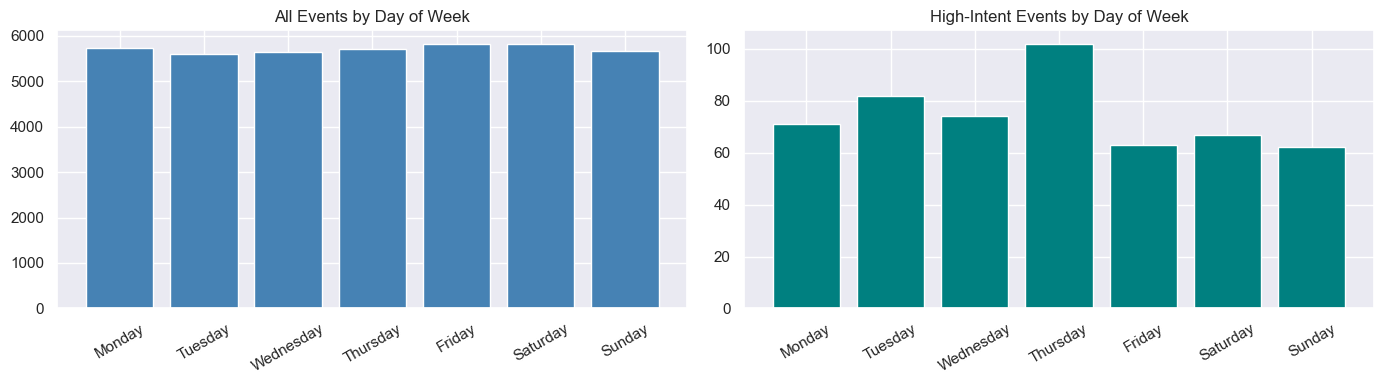

High-intent events by day:
day_of_week
Thursday     102
Tuesday       82
Wednesday     74
Monday        71
Saturday      67
Friday        63
Sunday        62

Key finding: Thursday generates the most high-intent events.


In [22]:
interactions["day_of_week"] = interactions["timestamp"].dt.day_name()
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

# All events by day
dow_all = (
    interactions.groupby("day_of_week")["interaction_id"]
    .count()
    .reindex(DOW_ORDER)
)

# High-intent events by day (filter inline)
dow_hi = (
    interactions[interactions["event_name"].isin(HIGH_INTENT_EVENTS)]
    .groupby("day_of_week")
    .size()
    .reindex(DOW_ORDER)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(DOW_ORDER, dow_all.values, color="steelblue")
axes[0].set_title("All Events by Day of Week")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(DOW_ORDER, dow_hi.values, color="teal")
axes[1].set_title("High-Intent Events by Day of Week")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../outputs/eda/day_of_week_patterns.png", dpi=150)
plt.show()

print("High-intent events by day:")
print(dow_hi.sort_values(ascending=False).to_string())
print()
print("Key finding: Thursday generates the most high-intent events.")

=== Time to Conversion ===
  Median : 30 days
  Mean   : 31 days
  Same day (< 1 day)  : 5 leads
  Within 7 days       : 23 leads
  Over 30 days        : 132 leads



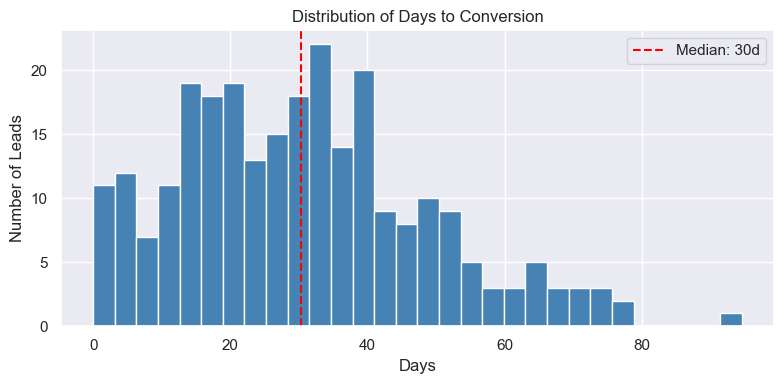

Key finding: Median 30-day sales cycle. Most conversions take weeks, not days.


In [23]:
# High-intent events (needed for time-to-conversion)
hi_events = interactions[interactions["event_name"].isin(HIGH_INTENT_EVENTS)].copy()

first_visit  = interactions.groupby("lead_id")["timestamp"].min()
first_intent = hi_events.groupby("lead_id")["timestamp"].min()

ttc = pd.DataFrame({
    "first_visit":  first_visit,
    "first_intent": first_intent
}).dropna()

ttc["days_to_convert"] = (
    (ttc["first_intent"] - ttc["first_visit"])
    .dt.total_seconds() / 86400
)

print("=== Time to Conversion ===")
print(f"  Median : {ttc['days_to_convert'].median():.0f} days")
print(f"  Mean   : {ttc['days_to_convert'].mean():.0f} days")
print(f"  Same day (< 1 day)  : {(ttc.days_to_convert < 1).sum()} leads")
print(f"  Within 7 days       : {(ttc.days_to_convert < 7).sum()} leads")
print(f"  Over 30 days        : {(ttc.days_to_convert > 30).sum()} leads")
print()

plt.figure(figsize=(8, 4))
plt.hist(ttc["days_to_convert"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(
    ttc["days_to_convert"].median(), color="red",
    linestyle="--", label=f"Median: {ttc['days_to_convert'].median():.0f}d"
)
plt.title("Distribution of Days to Conversion")
plt.xlabel("Days")
plt.ylabel("Number of Leads")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/eda/days_to_conversion.png", dpi=150)
plt.show()

print("Key finding: Median 30-day sales cycle. Most conversions take weeks, not days.")

In [24]:
ref_date = interactions["timestamp"].max()
last_visit = interactions.groupby("lead_id")["timestamp"].max()

engagement_span   = (last_visit - first_visit).dt.total_seconds().div(86400).clip(lower=0)
days_since_last   = (ref_date - last_visit).dt.total_seconds().div(86400).clip(lower=0)

# Avg session gap
interactions["date"] = interactions["timestamp"].dt.date
session_dates = (
    interactions.sort_values(["lead_id","timestamp"])
    .groupby(["lead_id","date"])["session_id"].nunique()
    .reset_index()
)
session_dates["date"] = pd.to_datetime(session_dates["date"])
session_dates = session_dates.sort_values(["lead_id","date"])
session_dates["gap_days"] = session_dates.groupby("lead_id")["date"].diff().dt.days
avg_gap = session_dates.groupby("lead_id")["gap_days"].mean()

temp_df = pd.DataFrame({
    "lead_id":               engagement_span.index,
    "engagement_span_days":  engagement_span.values,
    "days_since_last_visit": days_since_last.reindex(engagement_span.index).values,
    "avg_session_gap_days":  avg_gap.reindex(engagement_span.index).values,
}).reset_index(drop=True)

temp_df["converted"] = temp_df["lead_id"].isin(converted_ids).astype(int)

# Correlation
print("Correlation with conversion:")
for col in ["engagement_span_days", "days_since_last_visit", "avg_session_gap_days"]:
    corr = temp_df[col].corr(temp_df["converted"])
    print(f"  {col:30s}: {corr:+.4f}")

print()
print("Converted vs Not-converted averages:")
print(temp_df.groupby("converted")[["engagement_span_days","days_since_last_visit","avg_session_gap_days"]].mean().round(1).T.to_string())

Correlation with conversion:
  engagement_span_days          : +0.4626
  days_since_last_visit         : -0.1820
  avg_session_gap_days          : -0.2384

Converted vs Not-converted averages:
converted                 0     1
engagement_span_days   23.5  57.4
days_since_last_visit  80.9  65.1
avg_session_gap_days   12.0   8.1


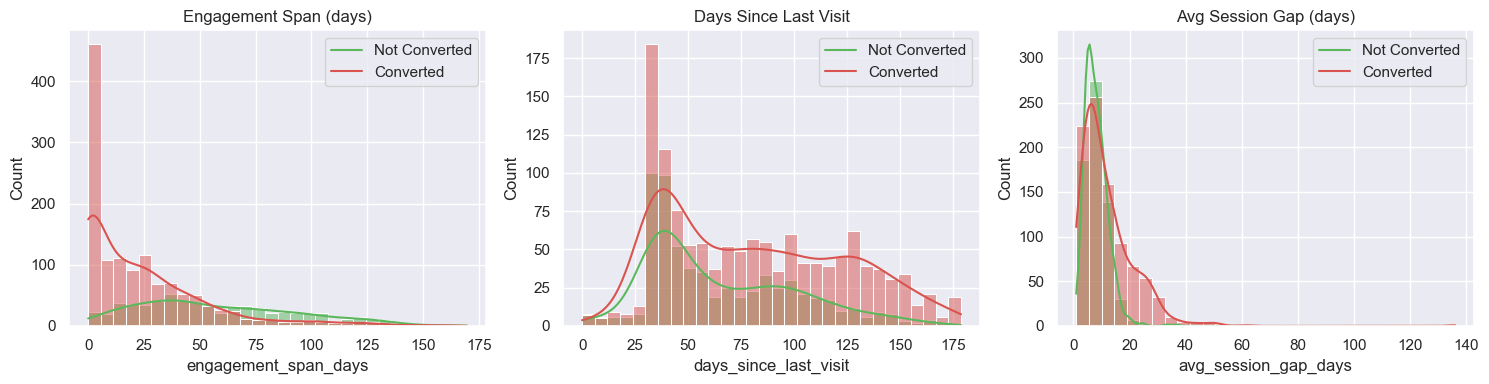

Key findings:
  engagement_span_days  : corr +0.46 — strongest temporal signal
  avg_session_gap_days  : corr -0.24 — tighter gap = habitual returner = converts more
  days_since_last_visit : corr -0.18 — recent leads convert more


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, title in zip(axes,
    ["engagement_span_days", "days_since_last_visit", "avg_session_gap_days"],
    ["Engagement Span (days)", "Days Since Last Visit", "Avg Session Gap (days)"]):
    sns.histplot(data=temp_df, x=col, hue="converted", bins=30, kde=True, ax=ax,
                 palette={0:"#d9534f", 1:"#5cb85c"})
    ax.set_title(title)
    ax.legend(["Not Converted","Converted"])

plt.tight_layout()
plt.savefig("../outputs/eda/temporal_features.png", dpi=150)
plt.show()

print("Key findings:")
print("  engagement_span_days  : corr +0.46 — strongest temporal signal")
print("  avg_session_gap_days  : corr -0.24 — tighter gap = habitual returner = converts more")
print("  days_since_last_visit : corr -0.18 — recent leads convert more")

## 8. Feature Correlation Heatmap

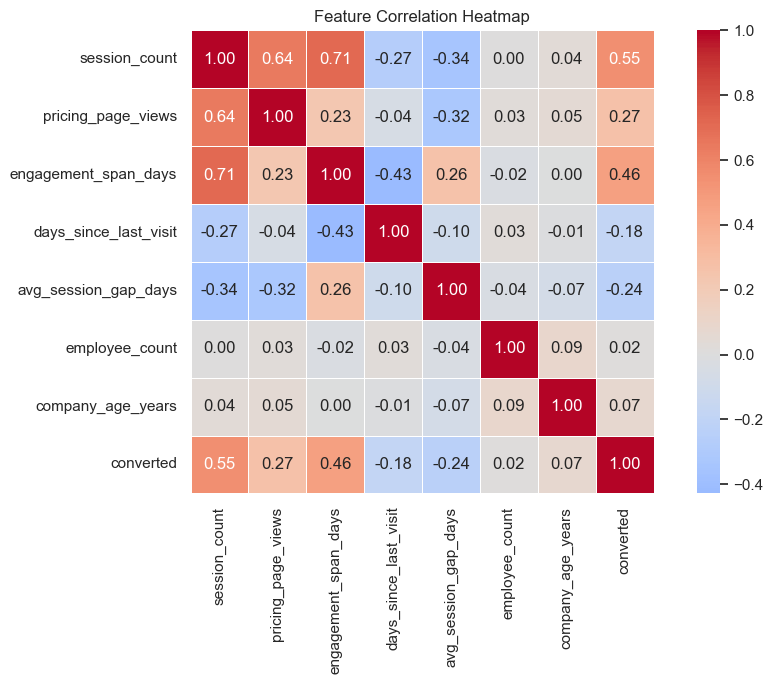

Key takeaways:
  engagement_span_days  — strongest positive correlation with conversion
  session_count         — positive correlation with conversion
  days_since_last_visit — negative correlation (older = less likely)
  No severe multicollinearity between selected features


In [26]:
# Build full numeric feature table for correlation
full = merged2.merge(temp_df[["lead_id","engagement_span_days","days_since_last_visit","avg_session_gap_days"]], on="lead_id", how="left")

numeric_features = [
    "session_count", "pricing_page_views",
    "engagement_span_days", "days_since_last_visit", "avg_session_gap_days",
    "employee_count", "company_age_years", "converted"
]
corr_matrix = full[[c for c in numeric_features if c in full.columns]].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../outputs/eda/correlation_heatmap.png", dpi=150)
plt.show()

print("Key takeaways:")
print("  engagement_span_days  — strongest positive correlation with conversion")
print("  session_count         — positive correlation with conversion")
print("  days_since_last_visit — negative correlation (older = less likely)")
print("  No severe multicollinearity between selected features")

## 9. Summary of Key Findings

| # | Finding | Business Action |
|---|---------|----------------|
| 1 | Decision-stage leads convert at 62% vs 2% for Awareness | Track funnel depth as top feature |
| 2 | Converted leads have 8 avg sessions vs 3.5 for non-converted | Use session_count in model |
| 3 | Instagram converts at 15% vs LinkedIn/Google at 37% | Review Instagram campaigns |
| 4 | Median sales cycle is 30 days | Don't stop nurturing before 30 days |
| 5 | March = peak volume + peak conversion | Replicate March conditions |
| 6 | Thursday has most high-intent events | Schedule sales outreach on Thursdays |
| 7 | Interns never convert (0%) | Filter interns from pipeline |
| 8 | Seed-stage companies convert at 21% vs Public at 35% | Prioritise Series A+ leads |
| 9 | engagement_span_days has +0.46 correlation with conversion | Add to model features |
| 10 | Pricing page viewed 2.8x more by converted leads | Trigger sales alert on 3rd pricing visit |

**Features to include in model:**
, , , ,
, , ,
, , 

**Features to EXCLUDE (data leakage):**
, , , 
